In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()
path = os.getenv("FASHIONGEN_HDF5_PATH")

In [2]:
print("hello")

hello


## 기본 EDA

In [4]:
# keys 출력
with h5py.File(path, "r") as f:
    for key in f.keys():
        print(key)

index
index_2
input_brand
input_category
input_composition
input_concat_description
input_department
input_description
input_gender
input_image
input_msrpUSD
input_name
input_pose
input_productID
input_season
input_subcategory


In [6]:
# 전체 이미지 개수
with h5py.File(path, "r") as f:
    total_size = f["input_image"].shape[0]
    print(f"Total dataset size: {total_size}")

Total dataset size: 260490


In [7]:
skip_indices = np.arange(0, 40, 4)

# 필요한 타입만 불러오기
with h5py.File(path, "r") as f:
    images = f["input_image"][skip_indices]
    desc_raw = f["input_concat_description"][skip_indices]
    cloth_types = f["input_subcategory"][skip_indices]

# bytes → str 변환
descriptions = []

for d in desc_raw:
    if isinstance(d, bytes):
        descriptions.append(d.decode("utf-8"))
    elif isinstance(d, np.ndarray):  # numpy string array일 수도 있음
        descriptions.append(d.tobytes().decode("utf-8").strip())
    else:
        descriptions.append(str(d))



## image-concat_description 시각화

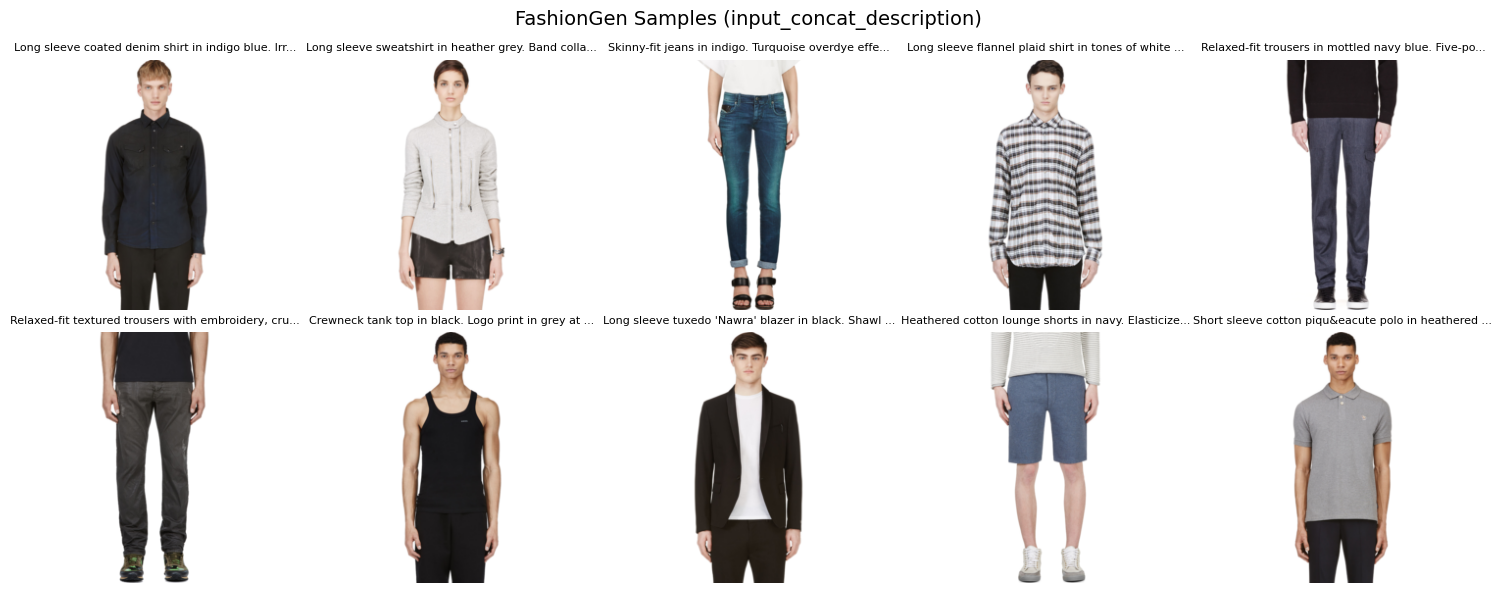

In [8]:
# 1. image-concat_description 시각화
plt.figure(figsize=(15, 6))
for i, (img, desc) in enumerate(zip(images, descriptions)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(desc[:50] + "..." if len(desc) > 50 else desc, fontsize=8)

plt.suptitle("FashionGen Samples (input_concat_description)", fontsize=14)
plt.tight_layout()
plt.show()


## 전체 데이터셋의 subcategory 종류 확인

In [6]:
# 2. 전체 데이터셋의 subcategory 종류 확인
print("Loading all subcategories from dataset...")

unique_cloth_types = set()

with h5py.File(path, "r") as f:
    total_size = f["input_subcategory"].shape[0]
    print(f"Total samples: {total_size}")
    
    for i in range(total_size):
        ct = f["input_subcategory"][i]
        
        if isinstance(ct, bytes):
            clean_ct = ct.decode("utf-8", errors='ignore').replace('\x00', '').strip()
        elif isinstance(ct, np.ndarray):
            clean_ct = ct.tobytes().decode("utf-8", errors='ignore').replace('\x00', '').strip()
        else:
            clean_ct = str(ct).replace('\x00', '').strip()
        
        if clean_ct:  # 빈 문자열 제외
            unique_cloth_types.add(clean_ct)
        
        # 진행상황 출력
        if (i + 1) % 10000 == 0:
            print(f"Processed {i + 1}/{total_size} samples...")

print(f"\nProcessing complete!")
print(f"\nTotal unique subcategories: {len(unique_cloth_types)}")
print("\nUnique Cloth Types in Dataset:")
for cloth_type in sorted(unique_cloth_types):
    print("-", cloth_type)

Loading all subcategories from dataset...
Total samples: 260490
Processed 10000/260490 samples...
Processed 20000/260490 samples...
Processed 30000/260490 samples...
Processed 40000/260490 samples...
Processed 50000/260490 samples...
Processed 60000/260490 samples...
Processed 70000/260490 samples...
Processed 80000/260490 samples...
Processed 90000/260490 samples...
Processed 100000/260490 samples...
Processed 110000/260490 samples...
Processed 120000/260490 samples...
Processed 130000/260490 samples...
Processed 140000/260490 samples...
Processed 150000/260490 samples...
Processed 160000/260490 samples...
Processed 170000/260490 samples...
Processed 180000/260490 samples...
Processed 190000/260490 samples...
Processed 200000/260490 samples...
Processed 210000/260490 samples...
Processed 220000/260490 samples...
Processed 230000/260490 samples...
Processed 240000/260490 samples...
Processed 250000/260490 samples...
Processed 260000/260490 samples...

Processing complete!

Total unique

### 상의류에 해당하는 type 정의

In [9]:
allowed_tops_with_outer = {
    "T-SHIRTS","SHIRTS","BLOUSES","POLOS","HENLEYS","CREWNECKS","V-NECKS",
    "TURTLENECKS","SHAWLNECKS","TANK TOPS","TANKS","TANK TOPS & CAMISOLES",
    "KNITS","CARDIGANS","SWEATSHIRTS","HOODIES & ZIPUPS","VESTS","WAISTCOATS",
    "BODYSUITS",
    "JACKETS","BLAZERS","BOMBERS","DENIM JACKETS","LEATHER JACKETS",
    "COATS","TRENCH COATS","PEACOATS","DOWN","FUR & SHEARLING",
}

pure_tops = {
    "T-SHIRTS","SHIRTS","BLOUSES","POLOS","HENLEYS","CREWNECKS","V-NECKS",
    "TURTLENECKS","SHAWLNECKS","TANK TOPS","TANKS","TANK TOPS & CAMISOLES",
    "KNITS","CARDIGANS","SWEATSHIRTS","HOODIES & ZIPUPS","VESTS","WAISTCOATS",
    "BODYSUITS",
}

In [10]:
# 상의류 카테고리 데이터 개수 확인
print("Counting samples in allowed tops categories...")

allowed_tops_with_outer = {
    "T-SHIRTS","SHIRTS","BLOUSES","POLOS","HENLEYS","CREWNECKS","V-NECKS",
    "TURTLENECKS","SHAWLNECKS","TANK TOPS","TANKS","TANK TOPS & CAMISOLES",
    "KNITS","CARDIGANS","SWEATSHIRTS","HOODIES & ZIPUPS","VESTS","WAISTCOATS",
    "BODYSUITS",
    "JACKETS","BLAZERS","BOMBERS","DENIM JACKETS","LEATHER JACKETS",
    "COATS","TRENCH COATS","PEACOATS","DOWN","FUR & SHEARLING",
}

count = 0

with h5py.File(path, "r") as f:
    total_size = f["input_subcategory"].shape[0]
    print(f"Total samples: {total_size}")
    
    for i in range(total_size):
        ct = f["input_subcategory"][i]
        
        # subcategory 디코딩
        if isinstance(ct, bytes):
            clean_ct = ct.decode("utf-8", errors='ignore').replace('\x00', '').strip()
        elif isinstance(ct, np.ndarray):
            clean_ct = ct.tobytes().decode("utf-8", errors='ignore').replace('\x00', '').strip()
        else:
            clean_ct = str(ct).replace('\x00', '').strip()
        
        # 허용된 카테고리에 해당하면 카운트
        if clean_ct in allowed_tops_with_outer:
            count += 1
        
        # 진행상황 출력
        if (i + 1) % 10000 == 0:
            print(f"Processed {i + 1}/{total_size} samples...")

print(f"\n=== Result ===")
print(f"Allowed tops samples: {count:,}")
print(f"Total samples: {total_size:,}")
print(f"Percentage: {count/total_size*100:.2f}%")

Counting samples in allowed tops categories...
Total samples: 260490
Processed 10000/260490 samples...
Processed 20000/260490 samples...
Processed 30000/260490 samples...
Processed 40000/260490 samples...
Processed 50000/260490 samples...
Processed 60000/260490 samples...
Processed 70000/260490 samples...
Processed 80000/260490 samples...
Processed 90000/260490 samples...
Processed 100000/260490 samples...
Processed 110000/260490 samples...
Processed 120000/260490 samples...
Processed 130000/260490 samples...
Processed 140000/260490 samples...
Processed 150000/260490 samples...
Processed 160000/260490 samples...
Processed 170000/260490 samples...
Processed 180000/260490 samples...
Processed 190000/260490 samples...
Processed 200000/260490 samples...
Processed 210000/260490 samples...
Processed 220000/260490 samples...
Processed 230000/260490 samples...
Processed 240000/260490 samples...
Processed 250000/260490 samples...
Processed 260000/260490 samples...

=== Result ===
Allowed tops s

In [11]:
# 해당 카테고리 데이터의 인덱스 저장
print("Finding indices of allowed tops categories...")

allowed_tops_with_outer = {
    "T-SHIRTS","SHIRTS","BLOUSES","POLOS","HENLEYS","CREWNECKS","V-NECKS",
    "TURTLENECKS","SHAWLNECKS","TANK TOPS","TANKS","TANK TOPS & CAMISOLES",
    "KNITS","CARDIGANS","SWEATSHIRTS","HOODIES & ZIPUPS","VESTS","WAISTCOATS",
    "BODYSUITS",
    "JACKETS","BLAZERS","BOMBERS","DENIM JACKETS","LEATHER JACKETS",
    "COATS","TRENCH COATS","PEACOATS","DOWN","FUR & SHEARLING",
}

tops_indices = []

with h5py.File(path, "r") as f:
    total_size = f["input_subcategory"].shape[0]
    print(f"Total samples: {total_size}")
    
    for i in range(total_size):
        ct = f["input_subcategory"][i]
        
        # subcategory 디코딩
        if isinstance(ct, bytes):
            clean_ct = ct.decode("utf-8", errors='ignore').replace('\x00', '').strip()
        elif isinstance(ct, np.ndarray):
            clean_ct = ct.tobytes().decode("utf-8", errors='ignore').replace('\x00', '').strip()
        else:
            clean_ct = str(ct).replace('\x00', '').strip()
        
        # 허용된 카테고리에 해당하면 인덱스 저장
        if clean_ct in allowed_tops_with_outer:
            tops_indices.append(i)
        
        # 진행상황 출력
        if (i + 1) % 10000 == 0:
            print(f"Processed {i + 1}/{total_size} samples...")

print(f"\n=== Result ===")
print(f"Total allowed tops samples: {len(tops_indices):,}")
print(f"Percentage: {len(tops_indices)/total_size*100:.2f}%")
print(f"\nFirst 10 indices: {tops_indices[:10]}")
print(f"Last 10 indices: {tops_indices[-10:]}")

# numpy array로 저장 (선택사항)
tops_indices = np.array(tops_indices)
print(f"\nIndices saved as numpy array with shape: {tops_indices.shape}")

Finding indices of allowed tops categories...
Total samples: 260490
Processed 10000/260490 samples...
Processed 20000/260490 samples...
Processed 30000/260490 samples...
Processed 40000/260490 samples...
Processed 50000/260490 samples...
Processed 60000/260490 samples...
Processed 70000/260490 samples...
Processed 80000/260490 samples...
Processed 90000/260490 samples...
Processed 100000/260490 samples...
Processed 110000/260490 samples...
Processed 120000/260490 samples...
Processed 130000/260490 samples...
Processed 140000/260490 samples...
Processed 150000/260490 samples...
Processed 160000/260490 samples...
Processed 170000/260490 samples...
Processed 180000/260490 samples...
Processed 190000/260490 samples...
Processed 200000/260490 samples...
Processed 210000/260490 samples...
Processed 220000/260490 samples...
Processed 230000/260490 samples...
Processed 240000/260490 samples...
Processed 250000/260490 samples...
Processed 260000/260490 samples...

=== Result ===
Total allowed t

In [12]:
np.save('tops_indices.npy', tops_indices)
print("Indices saved to 'tops_indices.npy'")

Indices saved to 'tops_indices.npy'


Loading all descriptions from dataset...
Total samples: 260490
Processed 10000/260490 samples...
Processed 20000/260490 samples...
Processed 30000/260490 samples...
Processed 40000/260490 samples...
Processed 50000/260490 samples...
Processed 60000/260490 samples...
Processed 70000/260490 samples...
Processed 80000/260490 samples...
Processed 90000/260490 samples...
Processed 100000/260490 samples...
Processed 110000/260490 samples...
Processed 120000/260490 samples...
Processed 130000/260490 samples...
Processed 140000/260490 samples...
Processed 150000/260490 samples...
Processed 160000/260490 samples...
Processed 170000/260490 samples...
Processed 180000/260490 samples...
Processed 190000/260490 samples...
Processed 200000/260490 samples...
Processed 210000/260490 samples...
Processed 220000/260490 samples...
Processed 230000/260490 samples...
Processed 240000/260490 samples...
Processed 250000/260490 samples...
Processed 260000/260490 samples...
Processing complete!

=== Descriptio

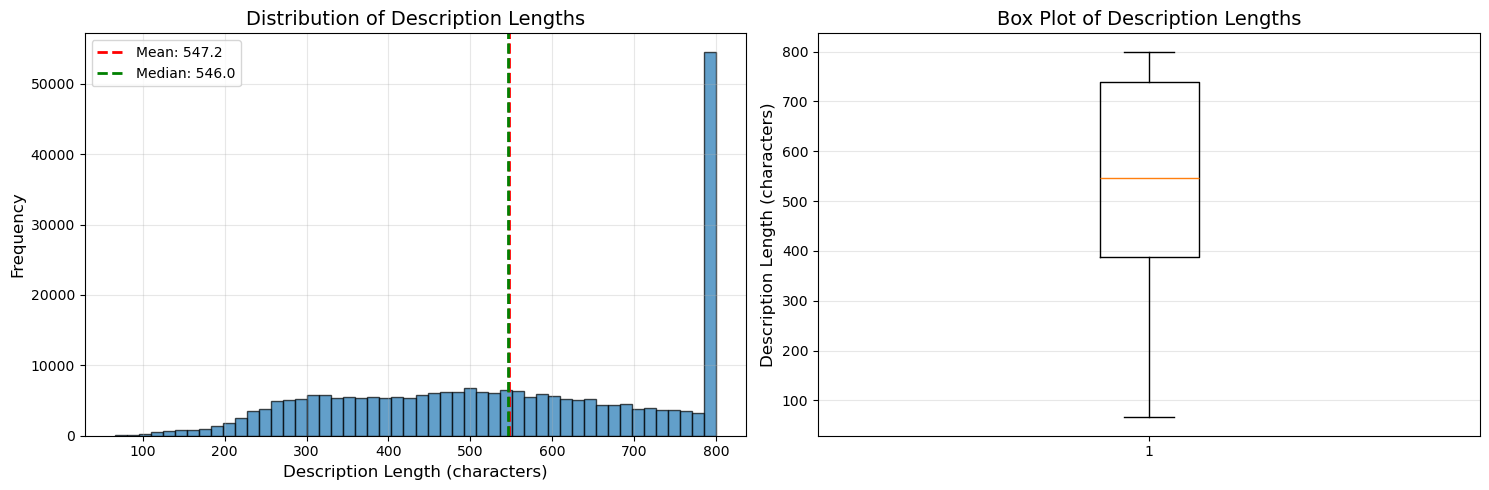

In [ ]:
# 3. 전체 데이터셋의 Description 길이 분포 확인
print("Loading all descriptions from dataset...")

actual_lengths = []

with h5py.File(path, "r") as f:
    total_size = f["input_concat_description"].shape[0]
    print(f"Total samples: {total_size}")
    
    # 전체 데이터 순회하며 길이만 계산
    for i in range(total_size):
        desc = f["input_concat_description"][i]
        
        # bytes → str 변환 (에러 무시)
        if isinstance(desc, bytes):
            desc_str = desc.decode("utf-8", errors='ignore')
        elif isinstance(desc, np.ndarray):
            desc_str = desc.tobytes().decode("utf-8", errors='ignore')
        else:
            desc_str = str(desc)
        
        # 패딩 제거 후 길이 계산
        cleaned = desc_str.rstrip().rstrip('\x00')
        actual_lengths.append(len(cleaned))
        
        # 진행상황 출력
        if (i + 1) % 10000 == 0:
            print(f"Processed {i + 1}/{total_size} samples...")

print("Processing complete!")

# 통계 출력
print("\n=== Description Length Statistics ===")
print(f"Total samples: {len(actual_lengths)}")
print(f"Min length: {min(actual_lengths)}")
print(f"Max length: {max(actual_lengths)}")
print(f"Mean length: {np.mean(actual_lengths):.2f}")
print(f"Median length: {np.median(actual_lengths):.2f}")
print(f"Std deviation: {np.std(actual_lengths):.2f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 히스토그램
axes[0].hist(actual_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Description Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Description Lengths', fontsize=14)
axes[0].axvline(np.mean(actual_lengths), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(actual_lengths):.1f}')
axes[0].axvline(np.median(actual_lengths), color='green', linestyle='--', 
                linewidth=2, label=f'Median: {np.median(actual_lengths):.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 박스플롯
axes[1].boxplot(actual_lengths, vert=True)
axes[1].set_ylabel('Description Length (characters)', fontsize=12)
axes[1].set_title('Box Plot of Description Lengths', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [13]:
# 800자 근처 샘플 확인
print("=== Samples near 800 characters ===")

near_800 = [i for i, length in enumerate(actual_lengths) if length >= 795]
print(f"Number of samples >= 795 chars: {len(near_800)}")
print(f"Percentage: {len(near_800)/len(actual_lengths)*100:.2f}%")

# 랜덤으로 3개 샘플 선택
random_samples = np.random.choice(near_800, size=min(3, len(near_800)), replace=False)

# 몇 개 샘플 확인
with h5py.File(path, "r") as f:
    for idx in random_samples:
        desc = f["input_concat_description"][idx]
        if isinstance(desc, bytes):
            desc_str = desc.decode("utf-8", errors='ignore')
        elif isinstance(desc, np.ndarray):
            desc_str = desc.tobytes().decode("utf-8", errors='ignore')
        else:
            desc_str = str(desc)
        
        cleaned = desc_str.rstrip().rstrip('\x00')
        print(f"\n[Index {idx}, Length: {len(cleaned)}]")
        print(cleaned[-100:])  # 마지막 100자 확인

=== Samples near 800 characters ===
Number of samples >= 795 chars: 52322
Percentage: 20.09%

[Index 227037, Length: 800]
 lanyard clasp fastening. Logo plaque at face. Foldover flap with magnetic press-stud fastening. Car

[Index 179094, Length: 800]
 Button closure at front. Patch pockets at waist. Graphic embroidered in red, white, and grey throug

[Index 245944, Length: 800]
ly. Silver-tone hardware. Contrast stitching in tan. Approx. 6.5" leg opening. Short sleeve cotton j


## 이미지를 256 -> 384 interpolation 시 이미지 확인

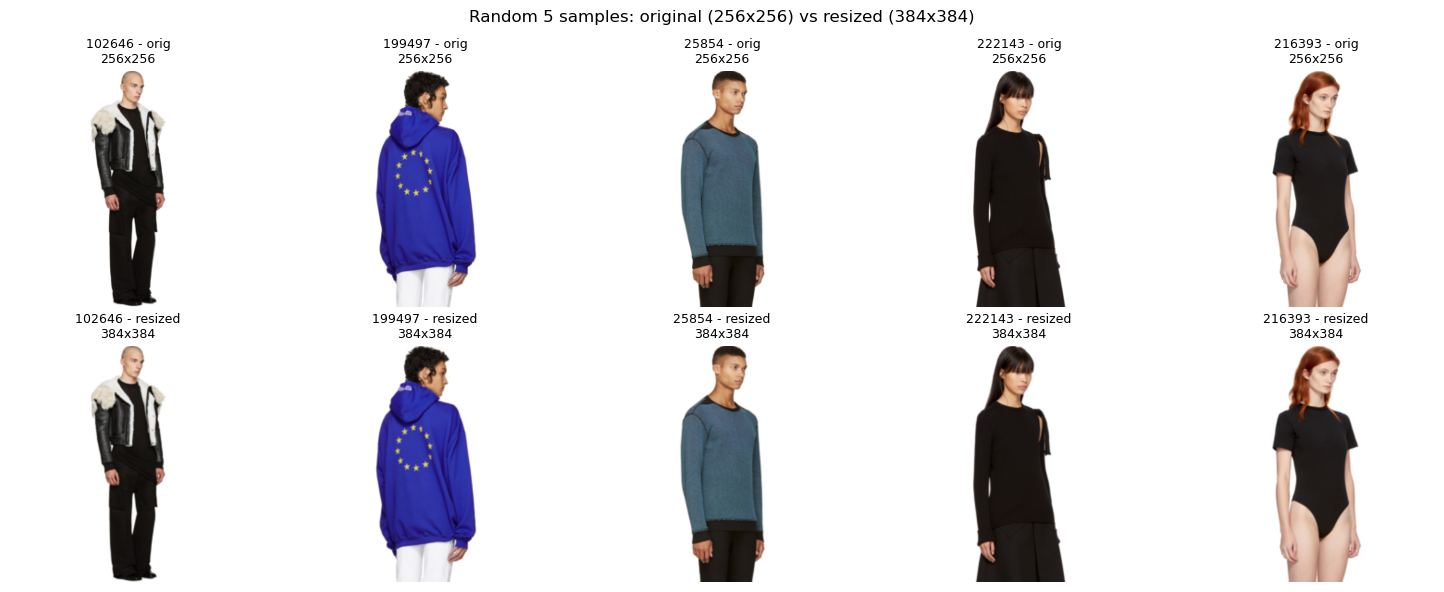

In [16]:
from PIL import Image

# 랜덤 5개 샘플 선택 (total_size가 없으면 HDF5에서 읽어옴)
if "total_size" not in globals():
    with h5py.File(path, "r") as f:
        total_size = f["input_image"].shape[0]

n = min(5, total_size)
indices = np.random.choice(total_size, size=n, replace=False)

orig_imgs = []
resized_imgs = []
with h5py.File(path, "r") as f:
    img_ds = f["input_image"]
    for idx in indices:
        arr = img_ds[int(idx)]
        pil_img = Image.fromarray(arr.astype("uint8")).convert("RGB")
        resized = pil_img.resize((384, 384), resample=Image.BICUBIC)
        orig_imgs.append(pil_img)
        resized_imgs.append(resized)

# 시각화: 상단 행 = 원본(256), 하단 행 = 리사이즈(384)
plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices):
    plt.subplot(2, n, i + 1)
    plt.imshow(orig_imgs[i])
    plt.axis("off")
    plt.title(f"{int(idx)} - orig\n256x256", fontsize=9)

    plt.subplot(2, n, n + i + 1)
    plt.imshow(resized_imgs[i])
    plt.axis("off")
    plt.title(f"{int(idx)} - resized\n384x384", fontsize=9)

plt.suptitle(f"Random {n} samples: original (256x256) vs resized (384x384)", fontsize=12)
plt.tight_layout()
plt.show()
